# Main QUEST 03 - GPT-1 구현 (Improving Language Understanding by Generative Pre-Training)

작성: 김민욱

논문 [Improving Language Understanding by Generative Pre-Training](https://cdn.openai.com/research-covers/language-unsupervised/language_understanding_paper.pdf) (Radford et al., OpenAI, 2018) 을 읽고,
내가 이전 노드(NLP02 챗봇 / NLP03 번역기)에서 만든 **인코더-디코더 Transformer** 를 **GPT-1(디코더 전용 언어모델)** 로 개조했다.

데이터는 챗봇 데이터(songys/Chatbot_data, 11,823쌍)를 쓰고, 논문의 1단계인 **사전학습(pretrain)만** 수행한다.
논문 3.2절의 지도 파인튜닝은 이번 과제 범위가 아니다.

## 목차

0. 먼저 알아야 할 용어와 수식 읽는 법 - 태스크, 함의, 목적함수, 수식 기호, perplexity
1. Transformer 와 비교해 무엇을 바꿔야 하는가 - 논문 정리와 변경점 8가지
2. 데이터 전처리 - 챗봇 데이터를 GPT 가 먹을 수 있는 모양으로
3. 모델의 입력 블록 - 토큰 임베딩 + 학습되는 위치 임베딩
4. GPT 모델 구성과 학습
5. 입력에 따른 출력 생성
6. 회고

(목차에 링크를 걸지 않았다. GitHub 은 노트북을 렌더링할 때 HTML 앵커를 지워버려서 링크가 엉뚱한 곳으로 튕긴다.)

<a id="0"></a>
# 0. 먼저 알아야 할 용어와 수식 읽는 법

논문을 읽다 보니 **모르는 용어와 수식**이 계속 나왔다. 그냥 넘어가면 나중에 이 노트북을 다시 열었을 때 나도 못 읽을 것 같아서, 먼저 정리하고 시작한다.

## 0-1. 용어

**태스크(task)** = 풀어야 할 **문제의 종류**. 번역, 감성분류, 질의응답 각각이 하나의 태스크다. "일감" 정도로 읽으면 된다.
논문이 "12개 태스크 중 9개에서 SOTA" 라고 하면 "12가지 일감 중 9개에서 1등" 이라는 뜻이다.

**함의(entailment)** = **"A가 참이면 B도 참인가?"** 를 판정하는 태스크. 논리학 용어다.

```
전제(A): 고양이가 매트 위에서 자고 있다.

가설(B): 동물이 실내에 있다.        -> 함의   (A가 참이면 B도 참)
가설(B): 고양이가 밖에서 뛰고 있다.  -> 모순   (A가 참이면 B는 거짓)
가설(B): 그 고양이는 세 살이다.      -> 중립   (A만 봐서는 알 수 없다)
```

문장 두 개를 넣고 이 셋 중 하나로 분류하는 문제다. 그래서 논문은 `<s> 전제 $ 가설 <e>` 처럼 **두 문장을 구분자로 이어붙여** 한 줄로 만들었다. 내가 챗봇 데이터를 `<bos> 질문 <sep> 답변 <eos>` 로 이어붙인 것과 **똑같은 발상**이다.

**목적함수(objective function)** = 학습 중에 **"모델이 잘하고 있는지"를 재는 단 하나의 숫자**, 그리고 그 숫자를 만드는 계산식.

학습은 이렇게 돌아간다.

```
1. 모델이 예측한다        ("오늘 날씨" 다음은? -> 단어마다 확률을 매긴다)
2. 목적함수가 채점한다     (정답 "좋다"에 높은 확률을 줬나? -> 숫자 하나)
3. 그 숫자가 좋아지는 방향으로 가중치를 조금 움직인다 (역전파)
4. 반복
```

**2번의 채점 기준이 목적함수다.** 이게 없으면 학습이 시작조차 안 된다. 무엇이 잘한 것인지 판단할 기준이 없기 때문이다.

## 0-2. 논문 식 (1) 읽기 - 이번 과제의 목적함수

$$L_1(\mathcal{U}) = \sum_i \log P(u_i \mid u_{i-k}, \dots, u_{i-1}; \Theta)$$

기호를 하나씩 뜯으면 이렇다.

| 기호 | 읽는 법 | 뜻 |
|---|---|---|
| $\mathcal{U}$ | 유 | 토큰 열 전체. `<bos> 12시 땡 ! <sep> 하루가 ...` |
| $u_i$ | 유 아이 | $i$ 번째 토큰 하나 |
| $\mid$ | (조건부 막대) | "~를 봤을 때" |
| $u_{i-k}, \dots, u_{i-1}$ | | $i$ 번째 **앞**에 있는 토큰 $k$ 개 (문맥 윈도우) |
| $P(u_i \mid \dots)$ | | **앞을 봤을 때 $i$ 번째 자리에 정답 토큰이 나올 확률** |
| $\log$ | 로그 | 확률(0~1)을 다루기 좋게 늘려주는 변환 |
| $\sum_i$ | 시그마 | **모든 자리 $i$ 에 대해 더한다** |
| $\Theta$ | 세타 | 모델의 가중치 전부 |

**말로 풀면 한 문장이다.**

> 문장의 **모든 자리마다**, 앞을 보고 그 자리의 **정답 토큰에 매긴 확률**을 (로그 씌워서) **전부 더한 값**. 이것을 크게 만들어라.

**실제 숫자로 해보자.** "오늘 날씨 좋다" 를 학습한다면,

```
자리 1: 앞을 보고 "오늘"이 정답.        모델이 준 확률 0.05 -> log(0.05) = -3.00
자리 2: "오늘"을 보고 "날씨"가 정답.     확률 0.30          -> log(0.30) = -1.20
자리 3: "오늘 날씨"를 보고 "좋다"가 정답. 확률 0.60          -> log(0.60) = -0.51
                                                          ─────────────────
                                                    L1 =    -4.71
```

확률이 **1에 가까울수록 로그는 0에 가까워지고**, 확률이 작을수록 로그는 **아주 큰 음수**가 된다.
그래서 **$L_1$ 을 최대화(0쪽으로 밀어올리기)** 하는 것이 곧 **정답 토큰의 확률을 1로 밀어올리는 것**이다.

**로그를 왜 씌우나?** 확률을 그냥 곱하면 `0.05 x 0.30 x 0.60 = 0.009` 처럼 순식간에 0으로 꺼져서 컴퓨터가 숫자를 제대로 다루지 못한다. 로그를 씌우면 **곱셈이 덧셈으로 바뀌어서**($\log(ab) = \log a + \log b$) 안전해진다.

**논문은 "최대화", 코드는 "최소화"** 인 것도 헷갈렸다. 같은 것이다. 코드에서는 부호를 뒤집어 **loss**(낮을수록 좋음)로 만들어 최소화한다. 위 예에서 loss 는 `4.71 / 3 = 1.57` 이다 (부호 뒤집고 토큰 수로 평균).

## 0-3. 논문 식 (2) 읽기 - 모델이 하는 계산

$$h_0 = U W_e + W_p$$
$$h_l = \text{transformer\_block}(h_{l-1}) \quad \forall l \in [1, n]$$
$$P(u) = \text{softmax}(h_n W_e^T)$$

| 기호 | 뜻 |
|---|---|
| $U$ | 입력 토큰 id 들 |
| $W_e$ | **토큰** 임베딩 표 [vocab, d_model]. "이 단어가 무슨 뜻인가" |
| $W_p$ | **위치** 임베딩 표 [max_len, d_model]. "이게 몇 번째 자리인가" |
| $h_0$ | 첫 번째 상태. 임베딩 두 개를 **더한 것** |
| $h_l$ | $l$ 번째 블록을 통과한 상태 |
| $\forall l \in [1, n]$ | "1부터 n 까지 모든 $l$ 에 대해" (블록을 n 번 쌓는다) |
| $h_n$ | 마지막 블록의 출력 |
| $W_e^T$ | 토큰 임베딩 표의 **전치**(행과 열을 뒤집은 것) |
| softmax | 숫자들을 **합이 1인 확률**로 바꾸는 함수 |

**세 줄을 말로 풀면:**

1. 토큰을 벡터로 바꾸고(뜻), 위치 벡터를 더한다(자리). 이게 $h_0$ 다.
2. 그 벡터를 트랜스포머 블록에 $n$ 번 통과시킨다. 매번 문맥이 더 잘 반영된다.
3. 마지막 출력에 **임베딩 표를 뒤집어 곱해서**, 8,000개 단어 각각의 확률을 얻는다.

3번이 이 논문의 특징이다. 새 출력 행렬을 만들지 않고 **입력 임베딩을 재사용**한다 ($W_e$ 가 1번과 3번에 **둘 다** 등장한다). "단어 -> 벡터" 표를 뒤집어 "벡터 -> 단어" 로 쓰는 것이다.

## 0-4. 학습 로그 읽는 법 (perplexity)

학습을 돌리면 아래 같은 줄이 에폭마다 찍힌다. 처음엔 무슨 소린지 몰랐다.

```
epoch 17 | lr 1.78e-04 | train 3.6284 (ppl 37.7) | val 4.7720 (ppl 118.2)
           └─학습률─┘    └── 학습 데이터 ──┘      └── 검증 데이터 ──┘
```

- **`train 3.6284`** = 학습 데이터에서의 **loss** (모델이 이미 본 문제)
- **`val 4.7720`** = 검증 데이터에서의 **loss** (모델이 한 번도 못 본 문제)
- **괄호 안의 `ppl`** = 그 loss 를 `exp()` 한 값. **loss 하나에 ppl 하나가 붙는 한 쌍**이다. 그래서 한 줄에 두 번 나온다.
  - `exp(3.6284) = 37.7`, `exp(4.7720) = 118.2` 로 실제로 딱 맞는다.

**perplexity(ppl) 를 읽는 법:**

> **"모델이 다음 단어를 고를 때, 몇 개의 후보를 놓고 헷갈리는가"**

우리 vocab 은 8,000개다.

| ppl | 뜻 |
|---|---|
| 8,000 | 8,000개를 전부 똑같이 찍고 있다 = **아무것도 모름** (학습 전) |
| 118 | 8,000개 중 **118개까지 좁혔다** |
| 37.7 | **37.7개까지 좁혔다** (더 잘한다) |
| 1 | 항상 정확히 맞힌다 (완벽. 현실에는 없다) |

**낮을수록 좋다.**

**train 과 val 의 차이가 핵심이다.**

```
train ppl  37.7  <- 이미 본 문제는 37개로 좁힌다
val   ppl 118.2  <- 처음 보는 문제는 118개로밖에 못 좁힌다
```

시험 공부로 치면, **기출문제는 답을 외워서 잘 푸는데 새 문제는 못 푸는 상태**다. 이 차이가 벌어질수록 "이해"가 아니라 "암기"를 하고 있다는 뜻이고, 그것이 **과적합**이다. 아래 4장에서 이 차이가 10배까지 벌어지는 것을 보게 된다.

<a id="1"></a>
# 1. Transformer 와 비교해 무엇을 바꿔야 하는가

## 1-1. 논문이 하려던 것

라벨 없는 텍스트(책, 웹)는 넘쳐나는데 **라벨 붙은 데이터는 귀하다.** 그래서 라벨 없는 데이터를 쓰고 싶은데, 2018년까지는 두 가지가 막혀 있었다.

1. 어떤 목적함수로 학습해야 전이(transfer)에 쓸모 있는 표현이 나오는지 합의가 없었다.
2. 학습한 표현을 태스크로 어떻게 옮길지도 합의가 없었다. 태스크마다 모델 구조를 새로 짜야 했다.

GPT-1 의 답은 이거다.

- **목적함수는 그냥 "다음 토큰 맞히기"(언어모델링) 하나로 한다.** 텍스트 자체가 정답지라서 라벨이 필요 없다.
- **옮길 때는 모델을 안 바꾸고 입력 모양만 바꾼다.** 태스크마다 문장을 한 줄로 이어붙이고(구분자 `$` 사용), 마지막에 선형층 하나만 새로 붙인다.

논문 3.1절의 사전학습 목적함수는 이렇다.

$$L_1(\mathcal{U}) = \sum_i \log P(u_i \mid u_{i-k}, \dots, u_{i-1}; \Theta)$$

앞의 $k$개 토큰을 보고 **바로 다음 토큰**을 맞힌다. 그게 전부다.

그리고 모델 계산은 세 줄이다 (논문 식 2).

$$h_0 = U W_e + W_p$$
$$h_l = \text{transformer\_block}(h_{l-1}) \quad \forall l \in [1, n]$$
$$P(u) = \text{softmax}(h_n W_e^T)$$

이 세 줄이 사실상 이번 과제의 설계도다. 여기서 두 가지가 원 Transformer 와 다르다.

- $W_p$ 가 **행렬**이다. sin/cos 수식이 아니라 **학습되는 위치 임베딩 표**다.
- $P(u)$ 에서 $W_e$ 가 **다시 등장한다** ($W_e^T$). 출력층 가중치를 따로 두지 않고 **입력 임베딩을 전치해 재사용**한다.

## 1-2. 논문의 모델 스펙 (4.1절)

| 항목 | 값 |
|---|---|
| 층 수 | 12 (디코더 블록) |
| d_model | 768 |
| 헤드 수 | 12 |
| FFN 내부 차원 | 3072 (= 768 x 4) |
| 문맥 길이 | 512 토큰 |
| 토크나이저 | BPE, 40,000 merges |
| 활성함수 | GELU |
| 위치정보 | 학습되는 위치 임베딩 |
| 옵티마이저 | Adam, 최대 lr 2.5e-4 |
| 스케줄 | 2000 스텝 선형 warmup 후 cosine 으로 0까지 감소 |
| 배치 / 에폭 | 64 x 512토큰, 100 에폭 |
| dropout | 0.1 (residual, embedding, attention) |
| 가중치 초기화 | N(0, 0.02) |
| 정규화 | L2 (w = 0.01, bias 와 gain 은 제외) |
| 데이터 | BooksCorpus (미출간 책 7,000권 넘음) |

BooksCorpus 를 고른 이유가 인상적이었다. 대안이던 1B Word Benchmark 는 **문장 단위로 섞여 있어서 장거리 구조가 깨진다.** 책은 긴 연속 텍스트라 모델이 멀리 있는 문맥에 의존하는 법을 배울 수 있다. 데이터의 "길이"가 아니라 "연속성"을 본 것이다.

## 1-3. 내 Transformer 에서 바꿔야 할 곳 - 변경점 8가지

내가 NLP02(챗봇) 와 NLP03(번역기) 에서 쓴 공용 구현(`transformer.py`, 인코더-디코더 구조)을 기준으로 정리했다.
아래 표의 [변경 N] 은 이 노트북의 코드 블록에 그대로 주석으로 달아뒀다.

| # | 내 Transformer (원본) | GPT-1 로 바꾼 것 | 근거 |
|---|---|---|---|
| 1 | `Encoder` 클래스가 있다 | **통째로 삭제.** 디코더 블록만 쌓는다 | 논문 3.1 "multi-layer Transformer **decoder**" |
| 2 | `DecoderLayer` 에 cross-attention (`enc_dec_attn` + `norm_3`) | **제거.** self-attention + FFN 2단만 남긴다 | 볼 인코더가 없다 |
| 3 | sin/cos 로 계산한 고정 위치 인코딩 (`register_buffer`) | **`nn.Embedding(max_len, d_model)`** 학습되는 표로 교체 | 논문 4.1 "learned position embeddings" |
| 4 | FFN 활성함수 `nn.ReLU()` | **`nn.GELU()`** | 논문 4.1 "Gaussian Error Linear Unit" |
| 5 | 마스크 3개 (`enc_mask`, `dec_enc_mask`, `dec_mask`) | **1개.** 패딩 OR 미래 | 인코더가 없으니 나머지 둘은 쓸 데가 없다 |
| 6 | 출력층 weight 를 임베딩과 공유 (`shared_fc`) | **유지.** 이미 논문대로였다 | 논문 식 (2) `softmax(h_n W_e^T)` |
| 7 | 임베딩에 `sqrt(d_model)` 을 곱함 | **제거** | 논문 식 (2) 에는 스케일링이 없다. 변경 3의 딸림 효과 |
| 8 | Noam 스케줄러 (`1/sqrt(step)`) | **warmup 후 cosine 감쇠** | 논문 4.1 |

### 변경 7을 왜 하는지 (내가 헷갈렸던 부분)

원 Transformer 는 임베딩에 `sqrt(d_model)` 을 곱한다. d_model=512 면 22.6배다. 왜냐하면 sin/cos 위치 인코딩은 값의 범위가 **-1 에서 1 로 고정**이라, 임베딩이 그보다 작으면 위치 정보가 단어 뜻을 덮어버리기 때문이다. 그래서 손으로 크기를 맞춰준 것이다.

그런데 GPT 는 위치도 **학습되는 임베딩**이다. 학습 중에 스스로 알맞은 크기를 찾아간다. 손으로 맞춰줄 이유가 사라졌고, 논문 식에도 없다. **변경 3을 하면 변경 7이 딸려 따라오는 구조**다.

## 1-4. 논문과 다르게 간 곳 (그리고 그 이유)

논문을 그대로 따르지 않은 곳이 두 군데 있다. 숨기지 않고 적어둔다.

**(가) Layer Norm 위치 - 논문은 Post-LN, 나는 Pre-LN 을 유지했다.**

논문 Figure 1 을 보면 GPT-1 은 어텐션 **뒤에** 정규화를 한다(Post-LN). 그런데 내 `transformer.py` 는 Pre-LN(서브레이어 **앞에서** 정규화)이고, 스택 끝에 `final_norm` 이 있다.

내가 NLP02 에서 직접 실험해본 적이 있다. `final_norm` 을 빼면 인코더 출력의 표준편차가 22.6까지 튀고(임베딩에 곱한 sqrt(d_model) 이 끝까지 살아남아서), 어텐션 확률이 한 자리에 0.89로 쏠려 답변이 전부 똑같아지는 모드 붕괴가 왔다. `final_norm` 을 넣으니 std 가 1.0, 최대 확률 0.13 으로 정상화됐다.

그 실험으로 얻은 구조를 이번에 버릴 이유가 없다. 게다가 **GPT-2 부터는 논문 저자들도 Pre-LN 으로 옮겨갔다.** 그래서 Pre-LN 을 유지한다.

**(나) 모델 크기 - 논문의 축소판으로 간다.**

논문은 12층 768차원이다. 우리 챗봇 데이터는 11,823쌍, 토큰으로 세면 **16만 개 남짓**이다. 논문 크기로 가면 파라미터가 데이터보다 수백 배 많아서 통째로 외워버린다. 그래서 **구조는 논문 그대로 두고 숫자만 줄인다** (6층 / 256차원). 아래에서 논문 스펙 모델도 같이 만들어 파라미터 수를 비교해본다.

<a id="2"></a>
# 2. 데이터 전처리 - 챗봇 데이터를 GPT 가 먹을 수 있는 모양으로

**평가기준 2** = "Decoder 기반의 생성모델임을 감안하여 챗봇 데이터를 변형합니다."

In [1]:
# 환경 준비
import os
import json
import math
import time
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import sentencepiece as spm

# 그래프에 한글이 깨지지 않게 폰트를 지정한다
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False   # 마이너스 기호가 네모로 깨지는 것 방지

# 재현성. seed를 고정해야 "이 숫자가 왜 나왔지"를 나중에 따라갈 수 있다
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch:", torch.__version__)
print("device:", device)

torch: 2.9.1+rocm7.2.1.gitff65f5bc
device: cuda


## 2-1. 원본 데이터 확인

한국어 챗봇 데이터(songys/Chatbot_data). 질문(Q) 과 답변(A) 이 쌍으로 있다.

In [2]:
# 데이터 로드. 로컬에 없으면 원본 저장소에서 받아온다
CSV_URL = "https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv"
LOCAL = "/home/gmw/Documents/AIFFEL_Work/_scratch/04_NLP/_shared/data/ChatbotData.csv"

df = pd.read_csv(LOCAL if os.path.exists(LOCAL) else CSV_URL)

print("행 수:", len(df))
print("컬럼:", list(df.columns))
print()
display(df.head())

# 문장 길이를 보자. GPT의 문맥 길이(=위치 임베딩 표의 행 수)를 정하는 근거가 된다
print("Q 글자수: 평균 %.1f, 최대 %d" % (df.Q.str.len().mean(), df.Q.str.len().max()))
print("A 글자수: 평균 %.1f, 최대 %d" % (df.A.str.len().mean(), df.A.str.len().max()))

행 수: 11823
컬럼: ['Q', 'A', 'label']



,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


Q 글자수: 평균 12.9, 최대 56
A 글자수: 평균 15.0, 최대 76


## 2-2. 왜 이대로는 GPT 에 못 넣는가

지금 데이터는 **두 칸으로 나뉜 표**다.

```
Q                    | A
---------------------|------------------
12시 땡!             | 하루가 또 가네요.
1지망 학교 떨어졌어  | 위로해 드립니다.
```

그런데 GPT 는 표를 못 먹는다. 논문 식 (1) 이 요구하는 입력은 **한 줄로 흐르는 토큰 열** 하나다.

$$L_1(\mathcal{U}) = \sum_i \log P(u_i \mid u_{i-k}, \dots, u_{i-1})$$

$\mathcal{U} = \{u_1, \dots, u_n\}$ 이 전부다. "질문 칸"과 "답변 칸" 같은 건 없다.

인코더-디코더 Transformer 는 이게 자연스러웠다. 인코더에 질문을 넣고 디코더에 답변을 넣으면 됐으니까. **그런데 GPT 는 인코더가 없다.** 넣을 곳이 한 군데뿐이다.

## 2-3. 해법 - 구분자를 끼워 한 줄로 잇는다

논문 3.3절이 정확히 이 문제를 다룬다. 함의(entailment) 태스크에서 전제와 가설을 이렇게 이어붙였다.

```
<s> Premise $ Hypothesis <e>
```

`$` 가 두 문장을 가르는 구분자(delimiter)다. **모델 구조를 바꾸지 않고 입력 모양만 바꿔서** 여러 문장을 한 줄로 만드는 것이다.

챗봇 데이터에 똑같이 적용한다.

```
<bos> 12시 땡 ! <sep> 하루가 또 가네요 . <eos>
      └─── 질문 ───┘      └──── 답변 ────┘
```

이렇게 만들어두면 **학습은 그냥 "다음 토큰 맞히기" 하나로 끝난다.** 질문/답변을 구분하는 별도 로직이 필요 없다.

그리고 여기서 공짜로 딸려오는 것이 있다. 학습이 끝나면 `<sep>` 다음에는 항상 답변이 온다는 걸 모델이 배운 상태가 된다. 그러니 **추론할 때 `<bos> 질문 <sep>` 까지만 주고 뒤를 이어서 생성시키면 그게 곧 답변**이다. 챗봇 기능이 언어모델링에서 저절로 나온다.

## 2-4. 토크나이저를 무엇으로 할까 - 두 가지를 재보고 고른다

문장을 토큰으로 쪼개는 방식을 정해야 한다. 후보가 둘이었다.

- **(A) SentencePiece BPE** - 논문 4.1 이 쓴 방식 (논문은 40,000 merges)
- **(B) MeCab 형태소** - 내가 NLP02 챗봇에서 쓴 방식

논문 방식이니까 그냥 A 로 갈 수도 있었지만, 어느 쪽이 우리 데이터에 맞는지 실제로 재보고 고르기로 했다.

In [3]:
# ---- (A) SentencePiece BPE 학습 ----
# 논문 4.1 = "bytepair encoding (BPE) vocabulary with 40,000 merges"
# 다만 우리 데이터는 11,823쌍(논문의 책 7,000권에 비하면 아주 작다)이라 40,000은 과하다.
# vocab 8,000으로 줄인다.

WORK = "."   # 노트북과 같은 폴더에 토크나이저 모델을 만든다

# SentencePiece가 학습할 말뭉치 = 질문과 답변을 구분 없이 한 줄씩
corpus_path = f"{WORK}/chatbot_corpus.txt"
with open(corpus_path, "w", encoding="utf-8") as f:
    for q, a in zip(df.Q, df.A):
        f.write(str(q).strip() + "\n")
        f.write(str(a).strip() + "\n")

spm.SentencePieceTrainer.train(
    input=corpus_path,
    model_prefix=f"{WORK}/chatbot_bpe",
    vocab_size=8000,
    model_type="bpe",                        # 논문과 같은 BPE
    pad_id=0, bos_id=1, eos_id=2, unk_id=3,  # 내 transformer.py 규약과 동일하게 맞춘다
    user_defined_symbols=["<sep>"],          # 질문/답변 구분자 (논문의 $ 역할)
    character_coverage=0.9995,
)

sp = spm.SentencePieceProcessor()
sp.load(f"{WORK}/chatbot_bpe.model")

PAD, BOS, EOS, UNK = 0, 1, 2, 3
SEP = sp.piece_to_id("<sep>")
VOCAB_SIZE = sp.get_piece_size()

print("BPE 학습 완료")
print("  vocab:", VOCAB_SIZE)
print("  특수토큰: PAD=%d BOS=%d EOS=%d UNK=%d SEP=%d" % (PAD, BOS, EOS, UNK, SEP))

BPE 학습 완료
  vocab: 8000
  특수토큰: PAD=0 BOS=1 EOS=2 UNK=3 SEP=4


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ./chatbot_corpus.txt
  input_format: 
  model_prefix: ./chatbot_bpe
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  user_defined_symbols: <sep>
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  

In [4]:
# ---- (B) MeCab 형태소 사전 (비교용) ----
# NLP02 챗봇에서 쓴 방식: 형태소로 쪼개고 빈도순으로 vocab을 만든다
from mecab import MeCab

mecab = MeCab()
counter = Counter()
for q, a in zip(df.Q, df.A):
    counter.update(mecab.morphs(str(q).strip()))
    counter.update(mecab.morphs(str(a).strip()))

specials = ["<pad>", "<bos>", "<eos>", "<unk>", "<sep>"]
itos_mecab = specials + [w for w, c in counter.most_common()]
stoi_mecab = {w: i for i, w in enumerate(itos_mecab)}

def encode_mecab(text):
    return [stoi_mecab.get(w, UNK) for w in mecab.morphs(str(text).strip())]

print("MeCab 사전 완료. vocab:", len(itos_mecab), "(이 데이터에 나온 형태소 종류 전부)")

MeCab 사전 완료. vocab: 6858 (이 데이터에 나온 형태소 종류 전부)


In [5]:
# ---- 두 방식으로 각각 <bos> 질문 <sep> 답변 <eos> 시퀀스를 만들어 비교 ----

def build_seqs(encode_fn, sep_id):
    out = []
    for q, a in zip(df.Q, df.A):
        out.append([BOS] + encode_fn(q) + [sep_id] + encode_fn(a) + [EOS])
    return out

seqs_bpe   = build_seqs(lambda t: sp.encode_as_ids(str(t).strip()), SEP)
seqs_mecab = build_seqs(encode_mecab, stoi_mecab["<sep>"])

len_bpe   = np.array([len(s) for s in seqs_bpe])
len_mecab = np.array([len(s) for s in seqs_mecab])

unk_bpe   = sum(s.count(UNK) for s in seqs_bpe)
unk_mecab = sum(s.count(UNK) for s in seqs_mecab)

print("%-22s %18s %18s" % ("항목", "SentencePiece BPE", "MeCab 형태소"))
print("-" * 60)
rows = [
    ("vocab 크기",        VOCAB_SIZE,                     len(itos_mecab)),
    ("시퀀스 평균 길이",   "%.1f" % len_bpe.mean(),        "%.1f" % len_mecab.mean()),
    ("시퀀스 최대 길이",   len_bpe.max(),                  len_mecab.max()),
    ("95% 분위수",        "%.0f" % np.percentile(len_bpe, 95),   "%.0f" % np.percentile(len_mecab, 95)),
    ("99% 분위수",        "%.0f" % np.percentile(len_bpe, 99),   "%.0f" % np.percentile(len_mecab, 99)),
    ("UNK 비율(%)",      "%.3f" % (100*unk_bpe/len_bpe.sum()), "%.3f" % (100*unk_mecab/len_mecab.sum())),
]
for name, a, b in rows:
    print("%-22s %18s %18s" % (name, a, b))

항목                      SentencePiece BPE          MeCab 형태소
------------------------------------------------------------
vocab 크기                             8000               6858
시퀀스 평균 길이                            14.2               18.4
시퀀스 최대 길이                              43                 52
95% 분위수                                21                 29
99% 분위수                                26                 35
UNK 비율(%)                           0.102              0.000


In [6]:
# 같은 문장을 어떻게 쪼개는지 눈으로 본다
for i in [0, 1, 11822]:
    print("원본 Q:", df.Q[i], "  /  A:", df.A[i])
    print("  BPE  :", sp.id_to_piece(seqs_bpe[i]))
    print("  MeCab:", [itos_mecab[t] for t in seqs_mecab[i]])
    print()

# 처음 보는 말(미등록어)에 어떻게 반응하는가 - 이게 진짜 시험이다
print("=" * 60)
print("학습 데이터에 없을 법한 말을 넣어본다")
print("=" * 60)
for t in ["갑분싸 왜 이래", "코로나19 확진자 폭증", "ㅋㅋㅋ 개웃김"]:
    n_unk = sum(1 for w in mecab.morphs(t) if w not in stoi_mecab)
    print("'%s'" % t)
    print("   BPE  :", sp.encode_as_pieces(t), "-> UNK 0개")
    print("   MeCab:", mecab.morphs(t), "-> UNK %d개" % n_unk)
    print()

원본 Q: 12시 땡!   /  A: 하루가 또 가네요.
  BPE  : ['<s>', '▁12', '시', '▁땡', '!', '<sep>', '▁하루가', '▁또', '▁가네요', '.', '</s>']
  MeCab: ['<bos>', '12', '시', '땡', '!', '<sep>', '하루', '가', '또', '가', '네요', '.', '<eos>']

원본 Q: 1지망 학교 떨어졌어   /  A: 위로해 드립니다.
  BPE  : ['<s>', '▁1', '지', '망', '▁학교', '▁떨어졌어', '<sep>', '▁위로해', '▁드립니다', '.', '</s>']
  MeCab: ['<bos>', '1', '지망', '학교', '떨어졌', '어', '<sep>', '위로', '해', '드립니다', '.', '<eos>']

원본 Q: 힘들어서 결혼할까봐   /  A: 도피성 결혼은 하지 않길 바라요.
  BPE  : ['<s>', '▁힘들어서', '▁결혼', '할까봐', '<sep>', '▁도', '피', '성', '▁결혼은', '▁하지', '▁않길', '▁바라요', '.', '</s>']
  MeCab: ['<bos>', '힘들', '어서', '결혼', '할까봐', '<sep>', '도피성', '결혼', '은', '하', '지', '않', '길', '바라', '요', '.', '<eos>']

학습 데이터에 없을 법한 말을 넣어본다
'갑분싸 왜 이래'
   BPE  : ['▁갑', '분', '싸', '▁왜', '▁이', '래'] -> UNK 0개
   MeCab: ['갑', '분', '싸', '왜', '이래'] -> UNK 1개

'코로나19 확진자 폭증'
   BPE  : ['▁코', '로', '나', '1', '9', '▁확', '진', '자', '▁폭', '증'] -> UNK 0개
   MeCab: ['코로나', '19', '확진', '자', '폭', '증'] -> UNK 3개

'ㅋㅋㅋ 개웃김'
   BPE  : ['▁', 'ᄏᄏ

### 비교 결과를 어떻게 읽었나

표만 보면 MeCab 이 이긴 것처럼 보인다. UNK 비율이 0.000% 니까.

**그런데 이건 착시다.** MeCab vocab 을 *이 데이터에 나온 형태소 전부* 로 만들었으니, 학습 데이터 안에서 UNK 가 안 나오는 건 당연하다. 시험 문제를 자기가 낸 셈이다.

**진짜 시험은 처음 보는 문장이다.** 마지막 블록이 그것이다.

```
'코로나19 확진자 폭증'
   BPE  : ['▁코','로','나','1','9','▁확','진','자','▁폭','증']   -> UNK 0개
   MeCab: ['코로나','19','확진','자','폭','증']                    -> UNK 3개
```

BPE 는 모르는 단어를 만나도 **글자 조각으로 쪼개서라도 표현**한다. MeCab 은 사전에 없으면 그냥 `<unk>` 라서 **정보가 통째로 증발한다.** 평가기준 5(입력에 따른 출력 생성)에서 내가 아무 문장이나 넣어볼 텐데, 그때 UNK 가 터지면 답변이 망가진다.

게다가 **BPE 가 시퀀스도 20% 넘게 짧다.** 학습이 그만큼 빠르고, 위치 임베딩 표도 작아진다.

**대신 BPE 의 약점도 있다.** `'도피성'` 을 BPE 는 `['▁도','피','성']` 으로 쪼갠다. **한국어 형태소 경계를 무시**한다. MeCab 은 `'도피성'` 하나로 잡는다. BPE 는 언어 지식이 없어서 의미 단위를 깨뜨릴 수 있다.

**결론: 미등록어에 강한 대신 의미 단위가 깨진다는 맞교환이고, 나는 BPE 를 고른다.** 논문이 쓴 방식이기도 하고, 생성 단계에서 UNK 가 안 터지는 게 더 중요하다고 봤다.

## 2-5. 문맥 길이(MAX_LEN) 정하기 - 위치 임베딩 표를 몇 행으로 할까

논문은 512다. 우리도 512로 해야 할까?

위치 임베딩은 **`nn.Embedding(행=위치개수, 열=d_model)`** 짜리 표다. 행 수가 곧 모델이 감당할 수 있는 최대 문장 길이다. 우리 문장이 짧은데 512행을 만들면, **대부분의 행이 학습 중에 거의 뽑히지 않아 갱신도 안 되는 죽은 파라미터**가 된다.

그래서 데이터를 보고 정한다.

길이 분위수 (BPE 기준)
   50.0% : 14 토큰
   90.0% : 19 토큰
   95.0% : 21 토큰
   99.0% : 26 토큰
  100.0% : 43 토큰


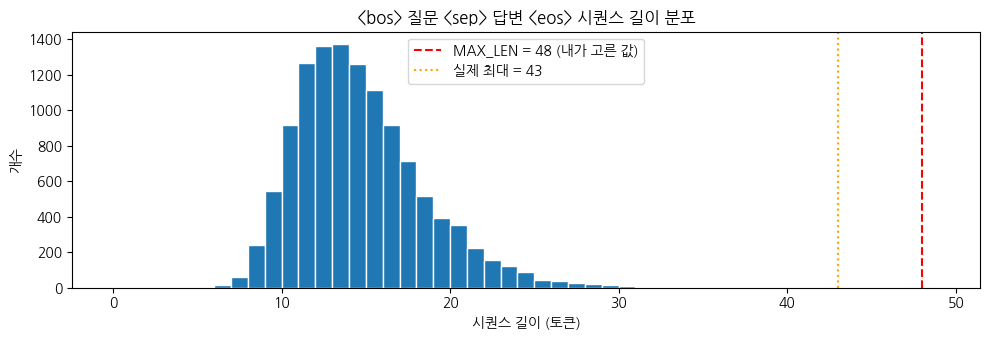


MAX_LEN = 48 -> 잘리는 시퀀스: 0 개
논문은 512. 우리는 48 이라 10분의 1도 안 된다. 챗봇 문장이 그만큼 짧다.


In [7]:
# BPE 기준 시퀀스 길이 분포
print("길이 분위수 (BPE 기준)")
for p in [50, 90, 95, 99, 100]:
    print("  %5.1f%% : %2.0f 토큰" % (p, np.percentile(len_bpe, p)))

plt.figure(figsize=(10, 3.5))
plt.hist(len_bpe, bins=range(0, 50), edgecolor="white")
plt.axvline(48, color="red", linestyle="--", label="MAX_LEN = 48 (내가 고른 값)")
plt.axvline(len_bpe.max(), color="orange", linestyle=":", label="실제 최대 = %d" % len_bpe.max())
plt.xlabel("시퀀스 길이 (토큰)"); plt.ylabel("개수")
plt.title("<bos> 질문 <sep> 답변 <eos> 시퀀스 길이 분포")
plt.legend(); plt.tight_layout(); plt.show()

MAX_LEN = 48
print()
print("MAX_LEN =", MAX_LEN, "-> 잘리는 시퀀스:", int((len_bpe > MAX_LEN).sum()), "개")
print("논문은 512. 우리는 48 이라 10분의 1도 안 된다. 챗봇 문장이 그만큼 짧다.")

가장 긴 시퀀스가 43토큰이라 **48행이면 한 문장도 안 잘린다.** 논문의 512 대비 10분의 1도 안 되지만, 우리 데이터에는 이게 맞는 크기다.

위치 임베딩 표 크기로 따지면 논문은 512 x 768 = 39만 파라미터, 우리는 48 x 256 = 1만 2천 파라미터다.

## 2-6. 학습용 텐서로 만들기 - 입력과 정답은 "한 칸 밀기"

언어모델의 정답은 **자기 자신을 한 칸 민 것**이다. 이게 "라벨이 필요 없다"의 실체다.

```
시퀀스:  <bos> 12시 땡 ! <sep> 하루가 또 가네요 . <eos>

입력 x:  <bos> 12시 땡 ! <sep> 하루가 또 가네요 .          (마지막 하나 뺀 것)
정답 y:        12시 땡 ! <sep> 하루가 또 가네요 . <eos>    (첫 하나 뺀 것)
```

`x` 의 0번 자리(`<bos>`) 를 보고 `y` 의 0번(`12시`) 를 맞히고, `x` 의 1번까지 보고 `y` 의 1번(`땡`) 을 맞힌다. **한 번의 forward 로 모든 자리를 동시에 학습**한다. 미래를 못 보게 마스크가 막아주기 때문에 컨닝이 안 된다.

In [8]:
# <bos> 질문 <sep> 답변 <eos> 로 한 줄 잇기 (평가기준 2의 핵심)
seqs = []
for q, a in zip(df.Q, df.A):
    ids = [BOS] + sp.encode_as_ids(str(q).strip()) + [SEP] \
                + sp.encode_as_ids(str(a).strip()) + [EOS]
    seqs.append(ids[:MAX_LEN])

# 패딩해서 [N, MAX_LEN] 행렬로. 0(PAD)으로 채운다
X = np.zeros((len(seqs), MAX_LEN), dtype=np.int64)
for i, s in enumerate(seqs):
    X[i, :len(s)] = s

# 학습/검증 9:1 분리. 과적합을 눈으로 보려면 검증셋이 반드시 필요하다
idx = np.random.permutation(len(X))
n_val = len(X) // 10
X_val, X_tr = X[idx[:n_val]], X[idx[n_val:]]

# 한 칸 밀기
def shift(arr):
    return torch.tensor(arr[:, :-1]), torch.tensor(arr[:, 1:])

x_tr, y_tr = shift(X_tr)
x_val, y_val = shift(X_val)

BATCH = 64   # 논문 4.1 = 64
tr_loader  = DataLoader(TensorDataset(x_tr, y_tr), batch_size=BATCH, shuffle=True)
val_loader = DataLoader(TensorDataset(x_val, y_val), batch_size=BATCH)

print("학습 시퀀스:", len(X_tr), " 검증 시퀀스:", len(X_val))
print("입력 x shape:", tuple(x_tr.shape), " 정답 y shape:", tuple(y_tr.shape))
print()
print("한 칸 밀기가 제대로 됐는지 확인 (첫 학습 샘플)")
print("  x:", sp.id_to_piece([int(t) for t in x_tr[0][:12]]))
print("  y:", sp.id_to_piece([int(t) for t in y_tr[0][:12]]))
print("  -> y 가 x 보다 정확히 한 칸 앞서 있으면 정상")

학습 시퀀스: 10641  검증 시퀀스: 1182
입력 x shape: (10641, 47)  정답 y shape: (10641, 47)

한 칸 밀기가 제대로 됐는지 확인 (첫 학습 샘플)
  x: ['<s>', '▁진심', '일까', '<sep>', '▁직접', '▁물어보세요', '.', '</s>', '<pad>', '<pad>', '<pad>', '<pad>']
  y: ['▁진심', '일까', '<sep>', '▁직접', '▁물어보세요', '.', '</s>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']
  -> y 가 x 보다 정확히 한 칸 앞서 있으면 정상


<a id="3"></a>
# 3. 모델의 입력 블록 - 토큰 임베딩 + 학습되는 위치 임베딩

**평가기준 3** = "모델의 입력 블럭을 GPT 논문에 기반하여 수정하였다. 모델의 input 이 정상적으로 구성되었는지 확인합니다. 데이터에 위치 정보를 추가하는 과정을 구현합니다."

논문 식 (2) 의 첫 줄이 입력 블록이다.

$$h_0 = U W_e + W_p$$

- $U$ : 토큰 id 시퀀스
- $W_e$ : **토큰** 임베딩 표 [vocab, d_model] - "이 단어가 무슨 뜻인가"
- $W_p$ : **위치** 임베딩 표 [max_len, d_model] - "이게 몇 번째 자리인가"

## 3-1. [변경 3] sinusoidal 에서 학습되는 임베딩으로

내 원본 `transformer.py` 는 이랬다.

```python
# 원본: sin/cos 로 표를 미리 계산해서 buffer 에 박아둔다 (학습 안 됨)
def positional_encoding(pos, d_model):
    ...
    sinusoid_table[:, 0::2] = np.sin(...)
    sinusoid_table[:, 1::2] = np.cos(...)
    return sinusoid_table

self.register_buffer("pos_encoding", torch.tensor(pos_encoding_np))
```

GPT 는 이걸 **학습되는 표**로 바꾼다 (논문 4.1: "We used learned position embeddings instead of the sinusoidal version").

```python
# GPT: 그냥 임베딩 레이어 하나. 역전파로 갱신된다
self.pos_emb = nn.Embedding(max_len, d_model)
```

### 둘의 차이를 정확히 알아두자 (내가 헷갈렸던 것)

learned 라고 해서 **상대적 거리**를 재는 게 아니다. **여전히 절대 위치다.** 0번 자리, 1번 자리에 각각 고유한 벡터를 준다는 점은 sinusoidal 과 똑같다.

다른 건 **그 벡터를 어디서 얻느냐** 뿐이다.

| | sinusoidal (원본) | learned (GPT) |
|---|---|---|
| 벡터를 얻는 법 | sin/cos 수식으로 계산 | 표에서 그 행을 꺼냄 |
| 파라미터 | 0개 (고정값) | max_len x d_model 개 |
| 역전파 | 안 받음 | **받음. 데이터에 맞게 갱신됨** |
| 학습 때 못 본 긴 문장 | 수식이라 얼마든지 계산 가능 | **불가능.** 표에 그 행이 없다 |

실행 시점에는 **둘 다 그냥 "표에서 행 꺼내기"** 다 (sinusoidal 도 매번 계산하지 않고 미리 만들어 캐싱해둔다). 유일한 차이는 그 표가 gradient 를 받느냐다.

### 그래서 learned 가 더 좋은가? 꼭 그렇지는 않다

원 Transformer 논문이 이미 둘 다 실험해보고 **"거의 동일한 결과(nearly identical)"** 라고 적었다.

> "We also experimented with using learned positional embeddings instead, and found that the two versions produced **nearly identical results**."
> — Vaswani et al. (2017), *Attention Is All You Need*, **3.5절 Positional Encoding** 마지막 문단 (실험 결과는 **Table 3 의 (E) 행**)

GPT-1 논문은 바꿨다는 사실만 적고 이유를 밝히지 않는다.

> "We used learned position embeddings instead of the sinusoidal version proposed in the original work."
> — Radford et al. (2018), **4.1절 Model specifications**

내 생각에 이유는 이렇다.

1. **외삽 능력을 버려도 손해가 없는 세팅이었다.** GPT-1 은 BooksCorpus 를 512토큰 덩어리로 잘라 학습한다. 학습도 512, 추론도 512다. 513번째 위치를 만날 일이 애초에 없으니, sinusoidal 의 유일한 장점(무한 외삽)이 **쓸모없는 장점**이 된다.
2. **비용이 하찮다.** 39만 파라미터는 GPT-1 전체(1억 1,700만) 의 0.3% 다.
3. **데이터가 충분하면 배우는 쪽이 밑질 게 없다.** sinusoidal 은 "위치는 이런 파형이어야 한다"고 사람이 정해준 것이고, learned 는 데이터에서 알아서 찾으라는 것이다.

즉 **"더 좋아서 바꿨다"기보다 "제약이 없으니 더 단순하고 유연한 쪽을 택했다"** 에 가깝다. 그리고 이 선택의 청구서는 나중에 날아온다. 요즘 모델들이 문맥 길이를 늘리려고 RoPE 같은 걸 새로 발명한 이유가 바로 이 "표의 행 수" 라는 벽이다.

In [9]:
# ---- 입력 블록만 따로 만들어서 눈으로 확인한다 (평가기준 3: input 정상 구성 확인) ----
d_model_demo = 256

tok_emb_demo = nn.Embedding(VOCAB_SIZE, d_model_demo, padding_idx=PAD)
pos_emb_demo = nn.Embedding(MAX_LEN, d_model_demo)      # [변경 3] 학습되는 위치 임베딩

# 실제 샘플 하나를 넣어본다
sample = x_tr[:1]                     # [1, 47]
b, L = sample.shape

# 위치 번호 만들기: [0, 1, 2, ..., L-1]
pos = torch.arange(L).unsqueeze(0)    # [1, L]

tok_vec = tok_emb_demo(sample)        # U We : [1, L, 256]  "무슨 뜻인가"
pos_vec = pos_emb_demo(pos)           # Wp   : [1, L, 256]  "몇 번째 자리인가"
h0 = tok_vec + pos_vec                # 논문 식 (2) 의 h_0

print("입력 토큰 id :", tuple(sample.shape), "->", [int(t) for t in sample[0][:8]], "...")
print("위치 번호    :", tuple(pos.shape),    "->", [int(t) for t in pos[0][:8]], "...")
print()
print("토큰 임베딩 U*We :", tuple(tok_vec.shape))
print("위치 임베딩 Wp   :", tuple(pos_vec.shape))
print("h0 = U*We + Wp   :", tuple(h0.shape))
print()
print("토큰 조각으로 보면:")
print(" ", sp.id_to_piece([int(t) for t in sample[0][:10]]))
print()
print("위치 임베딩 표 크기:", pos_emb_demo.weight.shape, "=", pos_emb_demo.weight.numel(), "개 파라미터")
print("이 표는 학습된다:", pos_emb_demo.weight.requires_grad)
print("(원본 transformer.py 의 sin/cos 표는 register_buffer 라 requires_grad=False 였다)")

입력 토큰 id : (1, 47) -> [1, 830, 775, 4, 555, 720, 6916, 2] ...
위치 번호    : (1, 47) -> [0, 1, 2, 3, 4, 5, 6, 7] ...

토큰 임베딩 U*We : (1, 47, 256)
위치 임베딩 Wp   : (1, 47, 256)
h0 = U*We + Wp   : (1, 47, 256)

토큰 조각으로 보면:
  ['<s>', '▁진심', '일까', '<sep>', '▁직접', '▁물어보세요', '.', '</s>', '<pad>', '<pad>']

위치 임베딩 표 크기: torch.Size([48, 256]) = 12288 개 파라미터
이 표는 학습된다: True
(원본 transformer.py 의 sin/cos 표는 register_buffer 라 requires_grad=False 였다)


## 3-2. 마스크 - [변경 5] 3개에서 1개로

원본 `generate_masks()` 는 마스크를 3개 반환했다.

| 마스크 | 무엇을 가리나 | GPT 에서는? |
|---|---|---|
| `enc_mask` | 인코더 self-attention 의 패딩 | **불필요.** 인코더가 없다 |
| `dec_enc_mask` | cross-attention 이 볼 src 패딩 | **불필요.** cross-attention 이 없다 |
| `dec_mask` | 디코더 self-attention 의 (패딩 OR 미래) | **이것만 남는다** |

GPT 는 자기 문장 하나만 보므로 마스크도 하나다. 그리고 여기서 **미래를 가리는 것**이 언어모델의 심장이다. 다음 토큰을 맞히는 문제인데 그 답이 입력에 보이면 그냥 베끼면 되니까, 학습이 아예 되지 않는다.

In [10]:
# [변경 5] 마스크 하나 - 패딩 OR 미래
# 규약: 1 = 가린다 (내 transformer.py 와 동일)

def generate_padding_mask(seq):
    """seq: [batch, L] -> [batch, 1, 1, L]. PAD(0) 자리가 1."""
    return (seq == PAD).unsqueeze(1).unsqueeze(2).float()

def generate_lookahead_mask(size, device=None):
    """[size, size]. i행 j열이 1 = i번째 토큰이 j(미래)를 못 본다."""
    return torch.triu(torch.ones(size, size, device=device), diagonal=1)

def generate_gpt_mask(x):
    """[batch, 1, L, L] - 패딩 OR 미래 (1 = 가린다)"""
    L = x.size(1)
    pad  = generate_padding_mask(x)                             # [b,1,1,L]
    look = generate_lookahead_mask(L, device=x.device)          # [L,L]
    look = look.unsqueeze(0).unsqueeze(1)                       # [1,1,L,L]
    return torch.max(pad, look)   # 1=가린다 규약에서 OR = 원소별 max


# 눈으로 확인: 짧은 시퀀스 하나로
demo = torch.tensor([[BOS, 100, 200, SEP, 300, EOS, PAD, PAD]])
m = generate_gpt_mask(demo)[0, 0]

print("입력:", ["<bos>", "tok", "tok", "<sep>", "tok", "<eos>", "<pad>", "<pad>"])
print()
print("마스크 (1 = 가린다). 행 = 보는 토큰, 열 = 보이는 토큰")
print("     ", "  ".join("%d" % i for i in range(8)))
for i in range(8):
    print("%2d | " % i, "  ".join("%d" % int(v) for v in m[i]))
print()
print("읽는 법:")
print("  0번 토큰(<bos>)의 행 -> 0번만 0(볼 수 있음), 나머지 전부 1(못 봄). 자기 자신만 본다")
print("  5번 토큰(<eos>)의 행 -> 0~5번은 0(볼 수 있음), 6~7번 패딩은 1(못 봄)")
print("  오른쪽 위 삼각형이 전부 1 = 미래를 못 본다 (언어모델의 심장)")

입력: ['<bos>', 'tok', 'tok', '<sep>', 'tok', '<eos>', '<pad>', '<pad>']

마스크 (1 = 가린다). 행 = 보는 토큰, 열 = 보이는 토큰
      0  1  2  3  4  5  6  7
 0 |  0  1  1  1  1  1  1  1
 1 |  0  0  1  1  1  1  1  1
 2 |  0  0  0  1  1  1  1  1
 3 |  0  0  0  0  1  1  1  1
 4 |  0  0  0  0  0  1  1  1
 5 |  0  0  0  0  0  0  1  1
 6 |  0  0  0  0  0  0  1  1
 7 |  0  0  0  0  0  0  1  1

읽는 법:
  0번 토큰(<bos>)의 행 -> 0번만 0(볼 수 있음), 나머지 전부 1(못 봄). 자기 자신만 본다
  5번 토큰(<eos>)의 행 -> 0~5번은 0(볼 수 있음), 6~7번 패딩은 1(못 봄)
  오른쪽 위 삼각형이 전부 1 = 미래를 못 본다 (언어모델의 심장)


<a id="4"></a>
# 4. GPT 모델 구성과 학습

**평가기준 4** = "GPT 모델을 정상적으로 구성하였다. (print(model), 훈련 진행과정 프린트 혹은 첨부). 노드의 transformer 코드를 수정하여 GPT1 모델을 구성합니다."

아래 코드는 내 `transformer.py` (NLP02/NLP03 공용 구현) 를 가져와 개조한 것이다. **바뀐 곳마다 `[변경 N]` 주석을 달았다.**

In [11]:
# ---------------------------------------------------------------------------
# Multi-Head Attention - 원본 transformer.py 그대로 (바꿀 이유가 없다)
# ---------------------------------------------------------------------------
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.0):
        super().__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads      # 헤드 하나가 담당하는 차원

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)

        self.attn_dropout = nn.Dropout(dropout)   # 논문 4.1 "attention dropout 0.1"

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        d_k = Q.size(-1)
        QK = torch.matmul(Q, K.transpose(-1, -2))
        scaled_qk = QK / math.sqrt(d_k)       # sqrt(d_k)로 나눠 softmax 쏠림을 막는다

        if mask is not None:
            # 가릴 자리(1)에 -1e9를 더해 softmax 확률을 0으로 보낸다.
            # -inf가 아닌 이유: 전부 패딩인 행에서 -inf는 0/0이 되어 nan을 뱉는다
            scaled_qk = scaled_qk + (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)
        out = torch.matmul(self.attn_dropout(attentions), V)
        return out, attentions

    def split_heads(self, x):
        b, L, _ = x.size()
        return x.view(b, L, self.num_heads, self.depth).permute(0, 2, 1, 3)

    def combine_heads(self, x):
        b, h, L, d = x.size()
        return x.permute(0, 2, 1, 3).contiguous().view(b, L, self.d_model)

    def forward(self, Q, K, V, mask=None):
        WQ, WK, WV = self.W_q(Q), self.W_k(K), self.W_v(V)
        out, attn = self.scaled_dot_product_attention(
            self.split_heads(WQ), self.split_heads(WK), self.split_heads(WV), mask
        )
        return self.linear(self.combine_heads(out)), attn


# ---------------------------------------------------------------------------
# [변경 4] FFN 활성함수: ReLU -> GELU  (논문 4.1)
#   ReLU는 0에서 뚝 꺾인다 (음수는 전부 0으로 죽인다).
#   GELU는 부드럽게 휘어서 작은 음수를 완전히 죽이지 않고 조금 통과시킨다.
# ---------------------------------------------------------------------------
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)    # 넓혔다가 (논문: 768 -> 3072)
        self.fc2 = nn.Linear(d_ff, d_model)    # 다시 좁힌다
        self.act = nn.GELU()                   # [변경 4] 원본은 nn.ReLU()

    def forward(self, x):
        return self.fc2(self.act(self.fc1(x)))

In [12]:
# ---------------------------------------------------------------------------
# [변경 2] GPTBlock = 원본 DecoderLayer 에서 cross-attention 을 제거한 것
#
#   원본 DecoderLayer 의 서브레이어는 3개였다:
#       1) masked self-attention   (자기 문장, 미래 가림)
#       2) cross-attention         (인코더 출력을 봄)   <- 삭제
#       3) feed forward
#   GPT는 볼 인코더가 없으므로 2)가 통째로 사라지고 2단만 남는다.
#   따라서 LayerNorm도 3개에서 2개로 준다.
# ---------------------------------------------------------------------------
class GPTBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        # Pre-LN: 서브레이어에 "들어가기 전"에 정규화한다
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        # [변경 2] 원본에 있던 self.norm_3 (cross-attention용) 이 사라졌다

        self.do = nn.Dropout(dropout)

    def forward(self, x, mask):
        # 1) Masked self-attention
        residual = x
        out = self.norm_1(x)
        out, attn = self.self_attn(out, out, out, mask=mask)
        out = self.do(out)
        out = out + residual

        # [변경 2] 여기 있던 cross-attention 서브레이어가 삭제됐다

        # 2) Feed Forward
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual

        return out, attn

In [13]:
# ---------------------------------------------------------------------------
# GPT 본체 - 논문 식 (2)
#     h_0  = U We + Wp
#     h_l  = transformer_block(h_(l-1))
#     P(u) = softmax(h_n We^T)
# ---------------------------------------------------------------------------
class GPT(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, vocab_size, max_len, dropout=0.1):
        super().__init__()
        self.max_len = max_len

        # We : 토큰 임베딩
        self.tok_emb = nn.Embedding(vocab_size, d_model, padding_idx=PAD)

        # [변경 3] Wp : 위치 임베딩. 원본은 sin/cos 고정 표(register_buffer)였다.
        #   논문 4.1 "learned position embeddings" -> 학습되는 nn.Embedding 으로 교체.
        #   대가: max_len 을 넘는 길이는 표에 행이 없어 영영 못 쓴다 (외삽 불가).
        self.pos_emb = nn.Embedding(max_len, d_model)

        self.do = nn.Dropout(dropout)

        # [변경 1] 원본의 Encoder 스택은 통째로 없다. 디코더 블록만 쌓는다.
        self.blocks = nn.ModuleList(
            [GPTBlock(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)   # Pre-LN의 필수 부품

        # [변경 6] 출력층 = 토큰 임베딩의 전치 (논문 식 2의 We^T).
        #   새 행렬을 만들지 않고 tok_emb.weight 를 그대로 재사용한다 (weight tying).
        #   "단어 -> 벡터" 표를 뒤집어 "벡터 -> 단어"로 쓰는 것.
        #   원본 transformer.py 의 shared_fc=True 와 같은 것이라 이건 이미 논문대로였다.
        self.fc = nn.Linear(d_model, vocab_size, bias=False)
        self.fc.weight = self.tok_emb.weight

        # 논문 4.1: "a simple weight initialization of N(0, 0.02) was sufficient"
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if isinstance(module, nn.Linear) and module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.LayerNorm):
            nn.init.ones_(module.weight)
            nn.init.zeros_(module.bias)

    def forward(self, x):
        """x: [batch, L] -> logits [batch, L, vocab], 레이어별 어텐션"""
        b, L = x.size()

        # 위치 번호 [0, 1, ..., L-1]
        pos = torch.arange(L, device=x.device).unsqueeze(0)

        # h_0 = U We + Wp   (논문 식 2)
        # [변경 7] 원본에 있던 out * sqrt(d_model) 스케일링이 없다.
        #   원본은 임베딩과 sin/cos(-1~1 고정 범위)의 크기를 맞추려고 곱했다.
        #   위치가 학습되는 임베딩이 되면 스스로 알맞은 크기를 찾아가므로 필요 없다.
        #   논문 식에도 스케일링이 없다.
        h = self.tok_emb(x) + self.pos_emb(pos)
        h = self.do(h)

        # [변경 5] 마스크 하나(패딩 OR 미래)로 전 블록을 통과
        mask = generate_gpt_mask(x)

        attns = []
        for block in self.blocks:
            h, attn = block(h, mask)
            attns.append(attn)
        h = self.final_norm(h)

        # P(u) = softmax(h_n We^T). softmax는 loss 함수가 하므로 여기선 logits까지
        logits = self.fc(h)
        return logits, attns

In [14]:
# ---------------------------------------------------------------------------
# [변경 8] 학습률 스케줄: Noam -> warmup 후 cosine 감쇠
#   논문 4.1 = "increased linearly from zero over the first 2000 updates and
#              annealed to 0 using a cosine schedule"
# ---------------------------------------------------------------------------
class WarmupCosineScheduler:
    def __init__(self, max_lr, warmup_steps, total_steps):
        self.max_lr = max_lr                # 논문 2.5e-4
        self.warmup_steps = warmup_steps    # 논문 2000
        self.total_steps = total_steps

    def __call__(self, step):
        step = max(1, step)
        if step < self.warmup_steps:
            return self.max_lr * step / self.warmup_steps       # 선형 증가
        progress = (step - self.warmup_steps) / max(1, self.total_steps - self.warmup_steps)
        return self.max_lr * 0.5 * (1.0 + math.cos(math.pi * min(1.0, progress)))


# ---------------------------------------------------------------------------
# 언어모델 손실 = 다음 토큰 예측 (논문 식 1)
#   패딩 자리는 loss에서 뺀다. 안 그러면 패딩이 많은 배치일수록 loss가 부당하게 작아진다
# ---------------------------------------------------------------------------
loss_object = nn.CrossEntropyLoss(reduction="none")

def lm_loss(logits, targets):
    mask = (targets != PAD).float()
    # CrossEntropyLoss는 클래스 차원이 두 번째여야 한다 -> transpose
    loss_ = loss_object(logits.transpose(1, 2), targets)
    return (loss_ * mask).sum() / mask.sum()

## 4-1. 모델 크기 정하기 - 논문 스펙 vs 우리 축소판

논문은 12층 / 768차원이다. 우리 데이터로 그 크기를 쓰면 어떻게 될까? 둘 다 만들어서 파라미터 수를 비교해본다.

In [15]:
def n_params(m):
    return sum(p.numel() for p in m.parameters())

# 논문 스펙 그대로 (4.1절)
paper_cfg = dict(n_layers=12, d_model=768, n_heads=12, d_ff=3072,
                 vocab_size=VOCAB_SIZE, max_len=512, dropout=0.1)
gpt_paper = GPT(**paper_cfg)

# 우리 데이터에 맞춘 축소판 - 구조는 그대로, 숫자만 줄인다
our_cfg = dict(n_layers=6, d_model=256, n_heads=8, d_ff=1024,
               vocab_size=VOCAB_SIZE, max_len=MAX_LEN, dropout=0.1)
model = GPT(**our_cfg).to(device)

# 데이터가 몇 토큰인지 (패딩 뺀 진짜 토큰)
total_tokens = int(sum(len(s) for s in seqs))

print("%-28s %16s %16s" % ("", "논문 스펙", "우리 축소판"))
print("-" * 62)
print("%-28s %16s %16s" % ("층 수",        paper_cfg["n_layers"], our_cfg["n_layers"]))
print("%-28s %16s %16s" % ("d_model",     paper_cfg["d_model"],  our_cfg["d_model"]))
print("%-28s %16s %16s" % ("헤드 수",      paper_cfg["n_heads"],  our_cfg["n_heads"]))
print("%-28s %16s %16s" % ("FFN 차원",     paper_cfg["d_ff"],     our_cfg["d_ff"]))
print("%-28s %16s %16s" % ("문맥 길이",     paper_cfg["max_len"],  our_cfg["max_len"]))
print("%-28s %16s %16s" % ("위치 임베딩 파라미터",
      "{:,}".format(gpt_paper.pos_emb.weight.numel()), "{:,}".format(model.pos_emb.weight.numel())))
print("%-28s %16s %16s" % ("전체 파라미터", "{:,}".format(n_params(gpt_paper)), "{:,}".format(n_params(model))))
print()
print("우리 학습 데이터의 토큰 수: {:,} 개".format(total_tokens))
print()
print("논문 스펙이면 파라미터가 데이터 토큰의 %.0f배다. 통째로 외워버린다." % (n_params(gpt_paper)/total_tokens))
print("축소판도 %.0f배라 과적합은 각오해야 한다. (논문은 이 비율이 정반대였다)" % (n_params(model)/total_tokens))

del gpt_paper   # 메모리 정리. 실제로 학습할 건 축소판이다

                                        논문 스펙           우리 축소판
--------------------------------------------------------------
층 수                                        12                6
d_model                                   768              256
헤드 수                                       12                8
FFN 차원                                   3072             1024
문맥 길이                                     512               48
위치 임베딩 파라미터                           393,216           12,288
전체 파라미터                            91,593,216        6,799,360

우리 학습 데이터의 토큰 수: 167,427 개

논문 스펙이면 파라미터가 데이터 토큰의 547배다. 통째로 외워버린다.
축소판도 41배라 과적합은 각오해야 한다. (논문은 이 비율이 정반대였다)


## 4-2. print(model) - 모델 구조 확인

**평가기준 4** 가 요구하는 `print(model)` 이다. 인코더가 없고 `GPTBlock` 6개만 쌓여 있는 것, 각 블록에 `self_attn` 과 `ffn` 만 있고 **cross-attention 이 없는 것**, `pos_emb` 가 `Embedding(48, 256)` 인 것을 확인할 수 있다.

In [16]:
print(model)
print()
print("파라미터 수: {:,}".format(n_params(model)))
print()
print("--- 논문대로 됐는지 확인 ---")
print("1. 인코더가 없다        :", not hasattr(model, "encoder"))
print("2. cross-attention 없다 :", not hasattr(model.blocks[0], "enc_dec_attn"))
print("3. 위치 임베딩이 학습된다:", model.pos_emb.weight.requires_grad, "(shape %s)" % str(tuple(model.pos_emb.weight.shape)))
print("4. FFN 활성함수         :", model.blocks[0].ffn.act)
print("5. weight tying (We^T)  :", model.fc.weight is model.tok_emb.weight)

GPT(
  (tok_emb): Embedding(8000, 256, padding_idx=0)
  (pos_emb): Embedding(48, 256)
  (do): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-5): 6 x GPTBlock(
      (self_attn): MultiHeadAttention(
        (W_q): Linear(in_features=256, out_features=256, bias=True)
        (W_k): Linear(in_features=256, out_features=256, bias=True)
        (W_v): Linear(in_features=256, out_features=256, bias=True)
        (linear): Linear(in_features=256, out_features=256, bias=True)
        (attn_dropout): Dropout(p=0.1, inplace=False)
      )
      (ffn): PoswiseFeedForwardNet(
        (fc1): Linear(in_features=256, out_features=1024, bias=True)
        (fc2): Linear(in_features=1024, out_features=256, bias=True)
        (act): GELU(approximate='none')
      )
      (norm_1): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
      (norm_2): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
      (do): Dropout(p=0.1, inplace=False)
    )
  )
  (final_norm): LayerNorm((256,), eps

In [17]:
# forward 한 번 통과시켜서 shape과 마스킹을 확인한다
model.eval()
with torch.no_grad():
    xb = x_tr[:2].to(device)
    logits, attns = model(xb)

print("입력  :", tuple(xb.shape),     "(배치, 길이)")
print("로짓  :", tuple(logits.shape), "(배치, 길이, vocab)")
print("어텐션: %d개 레이어, 각 %s (배치, 헤드, 길이, 길이)" % (len(attns), str(tuple(attns[0].shape))))
print()

# 미래를 정말 못 보는지 어텐션 확률로 검증한다
a = attns[0][0, 0].cpu()   # 첫 레이어, 첫 샘플, 첫 헤드
L = a.size(0)
upper = torch.triu(torch.ones(L, L), diagonal=1).bool()
print("미래 자리 어텐션 확률의 최대값: %.10f  (0이어야 정상)" % float(a[upper].max()))
print("0번 토큰이 보는 곳 (자기 자신만 1.0이어야):", [round(float(v), 3) for v in a[0][:5]])

입력  : (2, 47) (배치, 길이)
로짓  : (2, 47, 8000) (배치, 길이, vocab)
어텐션: 6개 레이어, 각 (2, 8, 47, 47) (배치, 헤드, 길이, 길이)

미래 자리 어텐션 확률의 최대값: 0.0000000000  (0이어야 정상)
0번 토큰이 보는 곳 (자기 자신만 1.0이어야): [1.0, 0.0, 0.0, 0.0, 0.0]


## 4-3. 학습 (사전학습, pretrain)

논문 3.1 의 $L_1$ 목적함수 하나만 최대화한다. 파인튜닝(논문 3.2)은 이번 과제 범위가 아니다.

학습 설정은 논문 4.1 을 따르되, 우리 데이터 크기에 맞게 조정한 곳이 있다.

| 항목 | 논문 | 우리 | 이유 |
|---|---|---|---|
| 최대 lr | 2.5e-4 | 2.5e-4 | 논문 그대로 |
| warmup | 2000 스텝 | 총 스텝의 10% | 논문은 100에폭이라 총 스텝이 크다. 우리 총 스텝이 작아서 비율로 맞췄다 |
| 스케줄 | cosine 으로 0까지 | 같음 | 논문 그대로 |
| 배치 | 64 | 64 | 논문 그대로 |
| dropout | 0.1 | 0.1 | 논문 그대로 |
| weight decay | 0.01 (bias/gain 제외) | 같음 | 논문 그대로 |
| 에폭 | 100 | 40 | 데이터가 훨씬 작다. 40에폭이면 검증 손실이 이미 바닥을 친다 |

GPU 에서 8분 정도 걸린다.

In [18]:
EPOCHS = 40
total_steps = EPOCHS * len(tr_loader)
WARMUP = int(total_steps * 0.1)    # 논문은 2000 스텝. 우리 총 스텝이 작아 비율(10%)로 맞춘다
MAX_LR = 2.5e-4                    # 논문 4.1

# 논문 4.1 = "modified version of L2 regularization, w=0.01 on all non bias or gain weights"
#   -> bias 와 LayerNorm 의 gain 에는 weight decay 를 걸지 않는다
decay, no_decay = [], []
for name, p in model.named_parameters():
    if p.dim() < 2 or "norm" in name:
        no_decay.append(p)          # bias, LayerNorm gain/bias
    else:
        decay.append(p)

optimizer = torch.optim.AdamW(
    [{"params": decay, "weight_decay": 0.01},
     {"params": no_decay, "weight_decay": 0.0}],
    lr=MAX_LR, betas=(0.9, 0.999),
)
sched = WarmupCosineScheduler(MAX_LR, WARMUP, total_steps)

print("에폭 %d, 스텝/에폭 %d, 총 %d 스텝, warmup %d 스텝" % (EPOCHS, len(tr_loader), total_steps, WARMUP))

에폭 40, 스텝/에폭 167, 총 6680 스텝, warmup 668 스텝


In [19]:
# 훈련 진행과정 프린트 (평가기준 4)
history = []
best_val = float("inf")
step = 0
t0 = time.time()

for ep in range(1, EPOCHS + 1):
    # ---- 학습 ----
    model.train()
    tr_loss = 0.0
    for xb, yb in tr_loader:
        xb, yb = xb.to(device), yb.to(device)

        step += 1
        lr = sched(step)                       # [변경 8] warmup 후 cosine
        for g in optimizer.param_groups:
            g["lr"] = lr

        logits, _ = model(xb)
        loss = lm_loss(logits, yb)             # 다음 토큰 예측 (논문 식 1)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)   # 발산 방어
        optimizer.step()
        tr_loss += loss.item()
    tr_loss /= len(tr_loader)

    # ---- 검증 ----
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits, _ = model(xb)
            val_loss += lm_loss(logits, yb).item()
    val_loss /= len(val_loader)

    # perplexity = exp(loss). "다음 토큰을 고를 때 몇 개 중에 헷갈리는가"로 읽는다
    ppl_tr, ppl_val = math.exp(tr_loss), math.exp(val_loss)
    history.append(dict(epoch=ep, lr=lr, train_loss=tr_loss, val_loss=val_loss,
                        train_ppl=ppl_tr, val_ppl=ppl_val))

    mark = ""
    if val_loss < best_val:
        best_val = val_loss
        torch.save({"model": model.state_dict(), "cfg": our_cfg, "max_len": MAX_LEN}, "gpt_best.pt")
        mark = "  <- best 저장"

    print("epoch %3d | lr %.2e | train %.4f (ppl %6.1f) | val %.4f (ppl %6.1f)%s"
          % (ep, lr, tr_loss, ppl_tr, val_loss, ppl_val, mark))

print()
print("총 %.1f초 걸렸다. best val loss = %.4f (ppl %.1f)" % (time.time()-t0, best_val, math.exp(best_val)))

epoch   1 | lr 6.25e-05 | train 8.0237 (ppl 3052.4) | val 7.2424 (ppl 1397.4)  <- best 저장
epoch   2 | lr 1.25e-04 | train 6.6730 (ppl  790.8) | val 6.2743 (ppl  530.8)  <- best 저장
epoch   3 | lr 1.88e-04 | train 6.0305 (ppl  415.9) | val 5.9149 (ppl  370.5)  <- best 저장
epoch   4 | lr 2.50e-04 | train 5.7296 (ppl  307.8) | val 5.6964 (ppl  297.8)  <- best 저장
epoch   5 | lr 2.50e-04 | train 5.4777 (ppl  239.3) | val 5.5061 (ppl  246.2)  <- best 저장
epoch   6 | lr 2.48e-04 | train 5.2555 (ppl  191.6) | val 5.3612 (ppl  213.0)  <- best 저장
epoch   7 | lr 2.46e-04 | train 5.0624 (ppl  158.0) | val 5.2322 (ppl  187.2)  <- best 저장
epoch   8 | lr 2.42e-04 | train 4.8836 (ppl  132.1) | val 5.1393 (ppl  170.6)  <- best 저장
epoch   9 | lr 2.38e-04 | train 4.7170 (ppl  111.8) | val 5.0679 (ppl  158.8)  <- best 저장
epoch  10 | lr 2.33e-04 | train 4.5570 (ppl   95.3) | val 4.9889 (ppl  146.8)  <- best 저장
epoch  11 | lr 2.27e-04 | train 4.4103 (ppl   82.3) | val 4.9361 (ppl  139.2)  <- best 저장
epoch  12 

## 4-4. 학습 곡선 - 과적합이 보인다

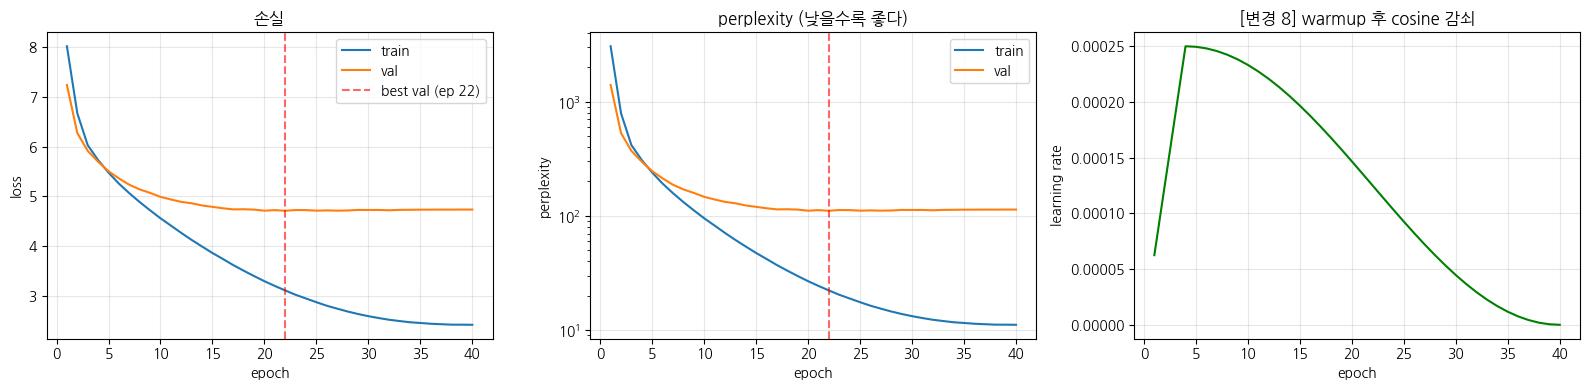

검증 손실이 가장 낮았던 에폭: 22 (val ppl 110.9)
마지막 에폭: train ppl 11.1 / val ppl 113.6 -> 차이 10.2배


In [20]:
h = pd.DataFrame(history)
best_ep = int(h.val_loss.idxmin()) + 1

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(h.epoch, h.train_loss, label="train")
axes[0].plot(h.epoch, h.val_loss, label="val")
axes[0].axvline(best_ep, color="red", linestyle="--", alpha=0.6, label="best val (ep %d)" % best_ep)
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].set_title("손실")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(h.epoch, h.train_ppl, label="train")
axes[1].plot(h.epoch, h.val_ppl, label="val")
axes[1].axvline(best_ep, color="red", linestyle="--", alpha=0.6)
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("perplexity"); axes[1].set_title("perplexity (낮을수록 좋다)")
axes[1].set_yscale("log"); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(h.epoch, h.lr, color="green")
axes[2].set_xlabel("epoch"); axes[2].set_ylabel("learning rate")
axes[2].set_title("[변경 8] warmup 후 cosine 감쇠")
axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print("검증 손실이 가장 낮았던 에폭: %d (val ppl %.1f)" % (best_ep, h.val_ppl[best_ep-1]))
print("마지막 에폭: train ppl %.1f / val ppl %.1f -> 차이 %.1f배"
      % (h.train_ppl.iloc[-1], h.val_ppl.iloc[-1], h.val_ppl.iloc[-1] / h.train_ppl.iloc[-1]))

학습 곡선을 보면 **검증 손실은 어느 시점부터 더 안 내려가는데 학습 손실은 계속 떨어진다.** 전형적인 과적합(암기)이다.

이건 실패라기보다 **논문이 왜 BooksCorpus(책 7,000권) 를 썼는지에 대한 실증**이다. 우리 데이터는 16만 토큰뿐인데 모델 파라미터는 680만 개다. 논문은 이 비율이 정반대(데이터가 모델보다 훨씬 크다)라서 외울 수가 없었고, 그래서 **외우는 대신 일반화된 언어 능력을 배울 수밖에 없었다.**

세 번째 그래프는 [변경 8] 로 바꾼 학습률 스케줄이다. 처음에 선형으로 올라갔다가 cosine 으로 0까지 내려온다.

<a id="5"></a>
# 5. 입력에 따른 출력 생성

**평가기준 5** = "입력에 따른 출력이 생성되었다. 출력 결과물의 수준에 상관없이 모델이 정상적으로 동작하는지 확인합니다."

여기서 짚고 싶은 게 있다. **나는 챗봇을 학습시킨 적이 없다.** "다음 토큰 맞히기"만 시켰다.

그런데 학습 중에 `<sep>` 다음에는 **항상 답변이 왔다.** 그러니 모델은 "`<sep>` 이 나오면 그 뒤엔 답변이 온다"는 걸 배운 상태다. 따라서 **`<bos> 질문 <sep>` 까지만 주고 뒤를 이어서 생성시키면 그게 곧 답변**이다.

챗봇 기능이 언어모델링에서 **저절로 딸려 나온다.** 논문이 zero-shot 분석에서 말한 것과 같은 현상이다.

In [21]:
# best 체크포인트를 불러온다 (마지막 에폭이 아니라 검증 손실이 가장 낮았던 시점)
ckpt = torch.load("gpt_best.pt", map_location=device)
model.load_state_dict(ckpt["model"])
model.eval()

@torch.no_grad()
def generate(question, max_new=30, temperature=1.0, top_k=0, greedy=False):
    """
    <bos> 질문 <sep> 까지 만들어 넣고, 그 뒤를 한 토큰씩 이어 붙인다.
      greedy=True : 항상 확률 1등을 고른다 (같은 질문이면 늘 같은 답)
      top_k > 0   : 상위 k개 중 확률에 따라 뽑는다 (답이 매번 달라진다)
    """
    ids = [BOS] + sp.encode_as_ids(question.strip()) + [SEP]

    for _ in range(max_new):
        # 위치 임베딩 표가 MAX_LEN행뿐이라 그 이상은 넣을 수 없다 ([변경 3] learned 방식의 대가)
        x = torch.tensor([ids[-MAX_LEN:]], device=device)
        logits, _ = model(x)
        next_logits = logits[0, -1, :]           # 맨 마지막 자리의 예측만 쓴다

        if greedy:
            nxt = int(next_logits.argmax())
        else:
            next_logits = next_logits / temperature
            if top_k > 0:
                v, _ = torch.topk(next_logits, top_k)
                next_logits[next_logits < v[-1]] = -float("inf")
            probs = F.softmax(next_logits, dim=-1)
            nxt = int(torch.multinomial(probs, 1))

        if nxt == EOS:
            break
        ids.append(nxt)

    return sp.decode_ids(ids[ids.index(SEP) + 1:])   # <sep> 뒤부터가 답변


tests = [
    "12시 땡!",                          # 학습 데이터에 있던 질문
    "1지망 학교 떨어졌어",                # 학습 데이터에 있던 질문
    "오늘 너무 힘들어",                   # 비슷하지만 없던 질문
    "여자친구랑 헤어졌어",
    "배고파 죽겠다",
    "내일 시험인데 공부 하나도 안 했어",   # 처음 보는 긴 질문
]

print("=" * 60)
print("greedy - 항상 확률 1등을 고른다")
print("=" * 60)
for q in tests:
    print("  Q:", q)
    print("  A:", generate(q, greedy=True))
    print()

greedy - 항상 확률 1등을 고른다
  Q: 12시 땡!
  A: 저도 좀 알려주세요.

  Q: 1지망 학교 떨어졌어
  A: 잘 이겨낼 수 있을 거예요.

  Q: 오늘 너무 힘들어
  A: 조금만 더 버텨보세요.

  Q: 여자친구랑 헤어졌어
  A: 좀 더 많이 아프겠어요.

  Q: 배고파 죽겠다
  A: 얼른 주무세요.

  Q: 내일 시험인데 공부 하나도 안 했어
  A: 지금도 늦지 않았어요.



In [22]:
print("=" * 60)
print("top-k 샘플링 (k=10, temperature=0.9) - 같은 질문도 매번 다르게")
print("=" * 60)
torch.manual_seed(42)
for q in tests[:4]:
    print("  Q:", q)
    for i in range(3):
        print("  A%d: %s" % (i + 1, generate(q, top_k=10, temperature=0.9)))
    print()

top-k 샘플링 (k=10, temperature=0.9) - 같은 질문도 매번 다르게
  Q: 12시 땡!
  A1: 저도 좋아해요.
  A2: 이제 내려봐요.
  A3: 이제 벗어나세요.

  Q: 1지망 학교 떨어졌어
  A1: 저도 궁금하네요.
  A2: 저도 같이 가요.
  A3: 이제 좀 챙겨드세요.

  Q: 오늘 너무 힘들어
  A1: 맛있는 거 드세요.
  A2: 오늘 오늘 좀 괜찮아졌길 바랍니다.
  A3: 맛있는 거 드세요.

  Q: 여자친구랑 헤어졌어
  A1: 좀 더 나은 사람들이군요.
  A2: 좀 더 이상하지 않아요.
  A3: 자신을 사랑해주세요.



/tmp/ipykernel_3408909/4070068799.py:20: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumGothic.
  plt.colorbar(); plt.tight_layout(); plt.show()
/home/gmw/anaconda3/envs/aiffel/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


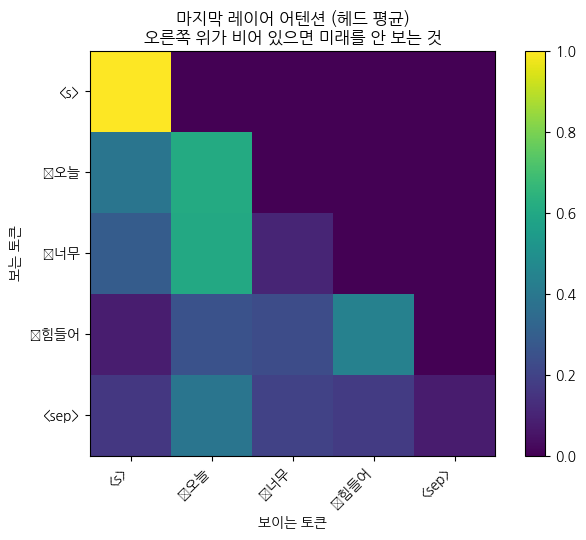

맨 아래 행이 <sep> 이다. 이 자리의 예측이 곧 답변의 첫 단어가 된다.
<sep> 이 질문의 어느 단어를 보고 있는지가 답변을 좌우한다.


In [23]:
# 어텐션이 실제로 무엇을 보고 있는지 (생성 결과의 근거)
q = "오늘 너무 힘들어"
ids = [BOS] + sp.encode_as_ids(q) + [SEP]
x = torch.tensor([ids], device=device)

model.eval()
with torch.no_grad():
    _, attns = model(x)

# 마지막 레이어, 헤드 평균. <sep> 자리(마지막)가 어디를 보는가
last = attns[-1][0].mean(0).cpu()          # [L, L] 헤드 평균
pieces = sp.id_to_piece(ids)

plt.figure(figsize=(7, 5.5))
plt.imshow(last, cmap="viridis")
plt.xticks(range(len(pieces)), pieces, rotation=45, ha="right")
plt.yticks(range(len(pieces)), pieces)
plt.xlabel("보이는 토큰"); plt.ylabel("보는 토큰")
plt.title("마지막 레이어 어텐션 (헤드 평균)\n오른쪽 위가 비어 있으면 미래를 안 보는 것")
plt.colorbar(); plt.tight_layout(); plt.show()

print("맨 아래 행이 <sep> 이다. 이 자리의 예측이 곧 답변의 첫 단어가 된다.")
print("<sep> 이 질문의 어느 단어를 보고 있는지가 답변을 좌우한다.")

<a id="6"></a>
# 6. 회고

## 6-1. 평가기준 대조

| 평가기준 | 어디서 했나 |
|---|---|
| 1. Transformer 와 비교해 변경이 필요한 부분을 서술 | 1장 (변경점 8가지 표) + 코드의 `[변경 N]` 주석 |
| 2. 모델의 입력 형태에 맞게 전처리 | 2장 (`<bos> 질문 <sep> 답변 <eos>` 로 한 줄 잇기, 토크나이저 비교 후 BPE 선택) |
| 3. 모델의 입력 블럭을 GPT 논문에 기반하여 수정 | 3장 (sinusoidal -> 학습되는 위치 임베딩, `h_0 = U We + Wp` 확인, 마스크 검증) |
| 4. GPT 모델을 정상적으로 구성 | 4장 (`print(model)`, 논문 스펙과 파라미터 비교, 훈련 진행과정 출력) |
| 5. 입력에 따른 출력이 생성 | 5장 (greedy / top-k 샘플링) |

## 6-2. 배운 것

**(1) "다음 단어 맞히기" 하나로 챗봇이 나온다.**

나는 챗봇을 학습시킨 적이 없다. 그런데 `<sep>` 뒤에 답변이 오도록 데이터를 이어붙여 놓기만 했더니, 언어모델이 그 규칙을 배워서 답변을 생성했다. **능력이 목적함수에서 저절로 자라 나온다**는 게 논문의 핵심 주장인데, 우리 축소판에서도 그게 보였다.

**(2) 위치 임베딩을 학습되는 표로 바꾼다는 게 무슨 뜻인지 이제 안다.**

처음엔 "학습되는 위치 = 상대 거리를 잰다"고 착각했다. 아니었다. **learned 도 여전히 절대 위치**다. 다른 건 그 벡터를 수식으로 계산하느냐(sinusoidal), 표에서 꺼내오느냐(learned) 뿐이다. 그리고 표로 바꾸는 순간 **행 수가 곧 문맥 상한**이 된다. 요즘 모델들이 "컨텍스트 128K" 를 광고하는 게 바로 이 표의 행 수 이야기라는 걸 알게 됐다.

**(3) 논문이 바꿨다고 다 우월한 건 아니다.**

learned position embedding 은 sinusoidal 보다 확실히 좋아서 바꾼 게 아니었다. **원 Transformer 논문이 이미 둘 다 실험하고 "거의 동일한 결과"라고 적어뒀다** (Vaswani et al. 2017, 3.5절 마지막 문단 / Table 3 의 (E) 행). GPT-1 이 learned 를 고른 건 **512 고정 길이로 학습하니 외삽 능력이 어차피 쓸모없었고, 파라미터 비용도 하찮았기 때문**에 가깝다 (Radford et al. 2018, 4.1절은 바꿨다는 사실만 적고 이유를 안 밝힌다).

논문을 따라가되 **"왜"를 묻고, 근거가 어디에 적혀 있는지까지 확인해야 한다**는 걸 배웠다.

## 6-3. 잘 안 된 것과 그 이유

**과적합.** 학습 손실은 계속 떨어지는데 검증 손실은 중간부터 안 내려갔다. 마지막에는 둘의 perplexity 가 10배 가까이 벌어졌다. 모델이 학습 데이터를 외운 것이다.

원인은 명확하다. **데이터가 너무 작다.** 챗봇 데이터는 토큰으로 16만 개뿐인데, 축소판 모델도 파라미터가 680만 개다. 논문의 BooksCorpus 는 책 7,000권이라 이 비율이 정반대였다. 외울 수 없으니 일반화할 수밖에 없었던 것이다.

그래서 생성 결과도 **문장은 멀쩡한데 내용이 엉뚱한** 경우가 있다. "배고파 죽겠다" 에 "얼른 주무세요" 라고 답하는 식이다. 문법(다음 토큰의 그럴듯함)은 배웠지만 의미는 덜 배웠다.

**해볼 수 있었던 것**: 데이터 증강(NLP02 에서 word2vec 유의어 치환을 써봤다), 더 작은 모델, dropout 을 0.1 보다 크게. 다만 이번 과제의 평가기준은 "출력 결과물의 수준에 상관없이 모델이 정상 동작하는지" 이므로, 과적합을 감추기보다 **왜 생기는지 정확히 짚는 쪽**을 택했다.

## 6-4. 다음에 해보고 싶은 것

- 논문 3.2 의 **파인튜닝**. 챗봇 데이터의 `label` 컬럼(일상/이별/사랑)이 그대로 분류 태스크가 된다. 사전학습한 이 모델에 선형층 하나만 붙이면 논문 식 (3) 이 된다. 보조 LM 손실($L_3 = L_2 + \lambda L_1$, $\lambda = 0.5$) 이 정말 도움이 되는지도 확인해볼 수 있다.
- **더 큰 코퍼스로 사전학습**한 뒤 챗봇 데이터로 파인튜닝. 논문의 주장을 그대로 재현하는 셈이다. 과적합이 사라지는지 보고 싶다.

<a id="ref"></a>
# 참고문헌

이 노트북에서 "논문이 이렇게 말했다" 라고 쓴 곳의 출처다. 나중에 다시 찾아볼 수 있게 절 번호까지 적어둔다.

**[1] Radford, Narasimhan, Salimans, Sutskever (2018). "Improving Language Understanding by Generative Pre-Training." OpenAI.**
[PDF](https://cdn.openai.com/research-covers/language-unsupervised/language_understanding_paper.pdf)

이번 과제의 논문. 내가 인용한 곳은 이렇다.

| 내가 쓴 내용 | 논문 위치 |
|---|---|
| 사전학습 목적함수 $L_1$ (다음 토큰 예측) | 3.1절, 식 (1) |
| 모델 계산 세 줄 ($h_0 = UW_e + W_p$ ... $P(u) = \text{softmax}(h_nW_e^T)$) | 3.1절, 식 (2) |
| "multi-layer Transformer decoder" 를 쓴다 | 3.1절 |
| 파인튜닝 = 선형층 $W_y$ 하나만 추가 | 3.2절, 식 (3)(4) |
| 보조 LM 손실 $L_3 = L_2 + \lambda L_1$ ($\lambda = 0.5$) | 3.2절, 식 (5) |
| 태스크별 입력 변환 (구분자 `$` 로 문장 잇기) | 3.3절, Figure 1 |
| 12층 / 768 / 12헤드 / FFN 3072 / 문맥 512 | 4.1절 Model specifications |
| BPE 40,000 merges | 4.1절 |
| GELU 활성함수 | 4.1절 |
| **learned position embeddings** (sinusoidal 대신) | 4.1절 |
| Adam 2.5e-4, warmup 2000 스텝 후 cosine 감쇠 | 4.1절 |
| dropout 0.1, 초기화 N(0, 0.02), L2 w=0.01 | 4.1절 |
| BooksCorpus 를 고른 이유 (1B Word Benchmark 는 문장 단위로 섞여 장거리 구조가 깨진다) | 4.1절 |
| 사전학습을 빼면 평균 14.8% 하락 / LSTM 으로 바꾸면 5.6 하락 | 5절 Ablation studies, Table 5 |
| zero-shot 성능이 사전학습 진행에 따라 오른다 | 5절 Zero-shot Behaviors, Figure 2 (오른쪽) |

**[2] Vaswani et al. (2017). "Attention Is All You Need." NeurIPS.**
[arXiv:1706.03762](https://arxiv.org/abs/1706.03762)

원 Transformer 논문. 내 `transformer.py` 의 뿌리이자, 이번에 "무엇을 바꿔야 하는가" 의 기준점이다.

| 내가 쓴 내용 | 논문 위치 |
|---|---|
| sinusoidal 위치 인코딩 (sin/cos 수식) | 3.5절 Positional Encoding |
| **"learned 와 sinusoidal 은 거의 동일한 결과(nearly identical)"** | **3.5절 마지막 문단, 실험은 Table 3 의 (E) 행** |
| 임베딩에 $\sqrt{d_{model}}$ 을 곱한다 | 3.4절 |
| 출력층 weight 를 임베딩과 공유한다 (weight tying) | 3.4절 |
| 어텐션에 dropout | 5.4절 Regularization |

**[3] 챗봇 데이터** - songys/Chatbot_data (한국어 챗봇 질문/답변 11,823쌍)
[github.com/songys/Chatbot_data](https://github.com/songys/Chatbot_data)

**[4] 내 이전 구현** - NLP02 (트랜스포머 챗봇), NLP03 (트랜스포머 번역기)
이번에 개조한 인코더-디코더 Transformer 의 원본. `final_norm` 이 없으면 모드 붕괴가 온다는 실험(1-4절에서 언급)도 NLP02 에서 한 것이다.